# Blanket Usage Prediction - Date-Only Model

## Purpose
This model predicts future blanket usage using **only date-based features** that are known in advance:
- Day of week
- Weekend indicator
- Month
- Day of month

**Why Date-Only?**
- AdmCount and DosaCount are not available for future dates (they haven't happened yet)
- This model can predict weeks or months ahead with certainty about input features
- More honest approach - doesn't rely on estimates or assumptions

**Trade-off:**
- Lower accuracy than the full model with admission data
- But predictions can be made immediately for any future date

In [17]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
from datetime import datetime, timedelta

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [18]:
# Load the data
df = pd.read_csv('LinenData.csv')

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# Extract date features
df['Month'] = df['Date'].dt.month
df['DayOfMonth'] = df['Date'].dt.day

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset shape: (348, 8)
Date range: 2024-12-03 00:00:00 to 2025-11-28 00:00:00

Columns: ['Date', 'AdmCount', 'DosaCount', 'DayOfWeekNum', 'IsWeekend', 'BlanketUsage', 'Month', 'DayOfMonth']


,Date,AdmCount,DosaCount,DayOfWeekNum,IsWeekend,BlanketUsage,Month,DayOfMonth
0,2024-12-03,11,3,2,0,15,12,3
1,2024-12-04,11,3,3,0,0,12,4
2,2024-12-05,3,0,4,0,0,12,5
3,2024-12-06,7,1,5,0,20,12,6
4,2024-12-07,6,0,6,1,0,12,7


## Baseline Model (for comparison)

In [19]:
# Define baseline model
def baseline_prediction(day_of_week):
    """
    Baseline rule:
    - Friday (5): 20
    - Tuesday (2): 15
    - Other days: 0
    """
    if day_of_week == 5:  # Friday
        return 20
    elif day_of_week == 2:  # Tuesday
        return 15
    else:
        return 0

# Apply baseline model
df['Baseline_Prediction'] = df['DayOfWeekNum'].apply(baseline_prediction)
print("✓ Baseline predictions generated")

✓ Baseline predictions generated


## Date-Only Random Forest Model

In [20]:
# Prepare features - ONLY DATE-BASED (no AdmCount or DosaCount)
date_only_features = ['DayOfWeekNum', 'IsWeekend', 'Month', 'DayOfMonth']

X = df[date_only_features]
y = df['BlanketUsage']

print("="*60)
print("DATE-ONLY MODEL FEATURES")
print("="*60)
print(f"Features: {date_only_features}")
print(f"Total samples: {len(X)}")
print(f"\nFeature Statistics:")
print(X.describe())
print("="*60)

DATE-ONLY MODEL FEATURES
Features: ['DayOfWeekNum', 'IsWeekend', 'Month', 'DayOfMonth']
Total samples: 348

Feature Statistics:
       DayOfWeekNum   IsWeekend       Month  DayOfMonth
count    348.000000  348.000000  348.000000  348.000000
mean       3.982759    0.275862    6.522989   15.752874
std        1.984011    0.447591    3.442745    8.453082
min        1.000000    0.000000    1.000000    1.000000
25%        2.000000    0.000000    4.000000    8.750000
50%        4.000000    0.000000    7.000000   16.000000
75%        6.000000    1.000000    9.000000   23.000000
max        7.000000    1.000000   12.000000   31.000000


In [21]:
# Split data into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

Training set size: 278 samples (79.9%)
Test set size:     70 samples (20.1%)


In [22]:
# Train Date-Only Random Forest model
print("Training Date-Only Random Forest model...")

rf_date_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_date_model.fit(X_train, y_train)
print("✓ Model training complete!")

Training Date-Only Random Forest model...
✓ Model training complete!


In [23]:
# Make predictions on test set
y_pred_date = rf_date_model.predict(X_test)

# Evaluate Date-Only model
date_r2 = r2_score(y_test, y_pred_date)
date_mae = mean_absolute_error(y_test, y_pred_date)
date_rmse = np.sqrt(mean_squared_error(y_test, y_pred_date))

print("="*60)
print("DATE-ONLY RANDOM FOREST PERFORMANCE (Test Set)")
print("="*60)
print(f"R² Score:                 {date_r2:.4f}")
print(f"Mean Absolute Error:      {date_mae:.4f}")
print(f"Root Mean Squared Error:  {date_rmse:.4f}")
print("="*60)

DATE-ONLY RANDOM FOREST PERFORMANCE (Test Set)
R² Score:                 0.9502
Mean Absolute Error:      0.9442
Root Mean Squared Error:  1.9608



Feature Importance:
        Feature  Importance
0  DayOfWeekNum    0.716578
2         Month    0.115653
3    DayOfMonth    0.101992
1     IsWeekend    0.065777


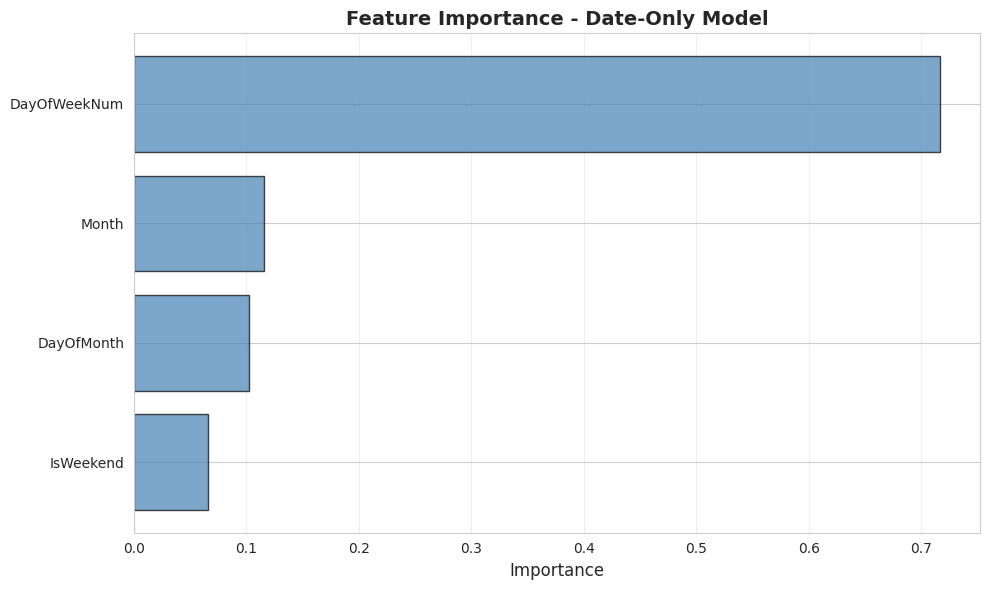

In [24]:
# Feature importance analysis
feature_importance = pd.DataFrame({
    'Feature': date_only_features,
    'Importance': rf_date_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], 
         color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance - Date-Only Model', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Model Comparison: Date-Only vs Baseline

In [25]:
# Get baseline predictions for test set
X_test_with_day = X_test.copy()
baseline_test_pred = X_test_with_day['DayOfWeekNum'].apply(baseline_prediction)

# Evaluate baseline on test set
baseline_test_mae = mean_absolute_error(y_test, baseline_test_pred)
baseline_test_rmse = np.sqrt(mean_squared_error(y_test, baseline_test_pred))
baseline_test_r2 = r2_score(y_test, baseline_test_pred)

# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': ['Baseline (Rule-Based)', 'Date-Only Random Forest'],
    'R² Score': [baseline_test_r2, date_r2],
    'MAE': [baseline_test_mae, date_mae],
    'RMSE': [baseline_test_rmse, date_rmse]
})

print("="*70)
print("MODEL COMPARISON (Test Set)")
print("="*70)
print(comparison.to_string(index=False))
print("="*70)

# Calculate improvement
mae_improvement = ((baseline_test_mae - date_mae) / baseline_test_mae) * 100
rmse_improvement = ((baseline_test_rmse - date_rmse) / baseline_test_rmse) * 100

print(f"\n📊 Date-Only Model Improvements over Baseline:")
print(f"   MAE improvement:  {mae_improvement:+.2f}%")
print(f"   RMSE improvement: {rmse_improvement:+.2f}%")

MODEL COMPARISON (Test Set)
                  Model  R² Score      MAE     RMSE
  Baseline (Rule-Based)  0.995376 0.071429 0.597614
Date-Only Random Forest  0.950228 0.944198 1.960771

📊 Date-Only Model Improvements over Baseline:
   MAE improvement:  -1221.88%
   RMSE improvement: -228.10%


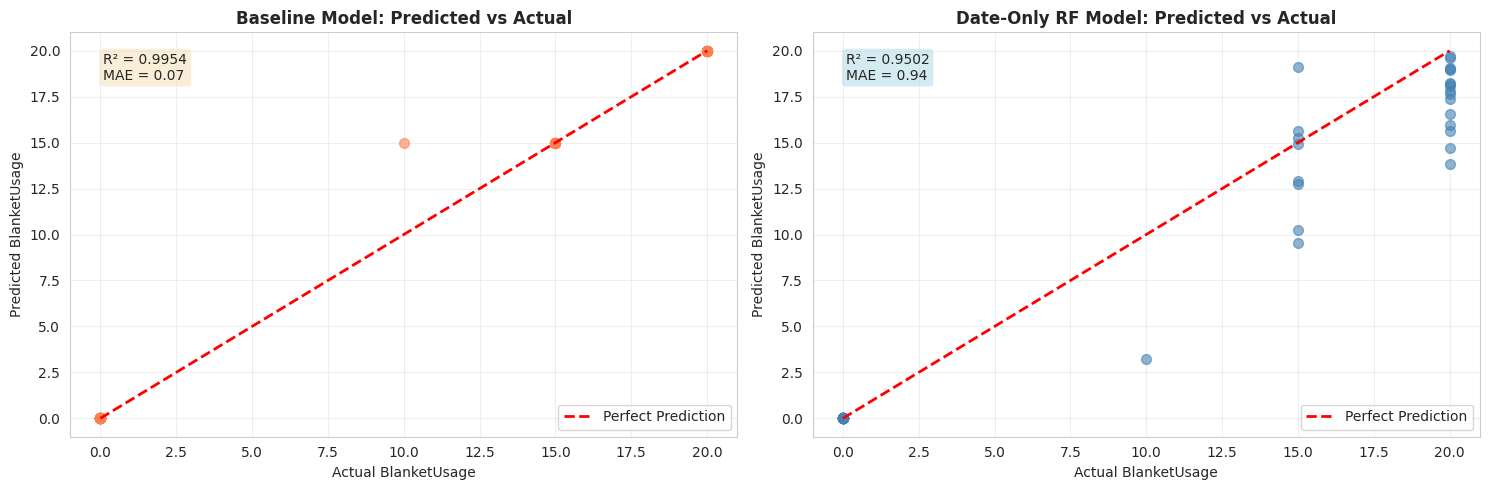

In [26]:
# Visualize predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Baseline predictions vs actual
axes[0].scatter(y_test, baseline_test_pred, alpha=0.6, s=50, color='coral')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_title('Baseline Model: Predicted vs Actual', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual BlanketUsage')
axes[0].set_ylabel('Predicted BlanketUsage')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].text(0.05, 0.95, f'R² = {baseline_test_r2:.4f}\nMAE = {baseline_test_mae:.2f}', 
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Date-Only RF predictions vs actual
axes[1].scatter(y_test, y_pred_date, alpha=0.6, color='steelblue', s=50)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_title('Date-Only RF Model: Predicted vs Actual', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual BlanketUsage')
axes[1].set_ylabel('Predicted BlanketUsage')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].text(0.05, 0.95, f'R² = {date_r2:.4f}\nMAE = {date_mae:.2f}', 
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

## Future Prediction Function

In [27]:
def predict_future_blankets(start_date, num_days, model=None, features=None):
    """
    Predict blanket usage for future dates using only date information.
    
    Parameters:
    -----------
    start_date : str or datetime
        Starting date for predictions (format: 'YYYY-MM-DD')
    num_days : int
        Number of days to predict
    model : sklearn model (optional)
        Trained model. If None, will load from file
    features : list (optional)
        List of feature names. If None, will load from file
    
    Returns:
    --------
    DataFrame with predictions
    """
    # Load model if not provided
    if model is None:
        model = joblib.load('blanket_usage_date_only_model.pkl')
    if features is None:
        features = joblib.load('date_only_features.pkl')
    
    # Create future dates
    start = pd.to_datetime(start_date)
    future_dates = pd.date_range(start=start, periods=num_days, freq='D')
    
    # Create dataframe
    future_df = pd.DataFrame({'Date': future_dates})
    
    # Extract date features
    future_df['DayOfWeekNum'] = future_df['Date'].dt.dayofweek + 1  # 1=Monday, 7=Sunday
    future_df['IsWeekend'] = (future_df['DayOfWeekNum'] >= 6).astype(int)
    future_df['Month'] = future_df['Date'].dt.month
    future_df['DayOfMonth'] = future_df['Date'].dt.day
    future_df['DayName'] = future_df['Date'].dt.day_name()
    
    # Make predictions
    X_future = future_df[features]
    future_df['RF_Prediction'] = model.predict(X_future)
    future_df['RF_Prediction'] = future_df['RF_Prediction'].round().astype(int).clip(lower=0)
    
    # Add baseline prediction for comparison
    future_df['Baseline_Prediction'] = future_df['DayOfWeekNum'].apply(baseline_prediction)
    
    return future_df

print("✓ Future prediction function created")

✓ Future prediction function created


## Example: Predict Next 30 Days

In [28]:
# Predict next 30 days from the last date in the dataset
last_date = df['Date'].max()
start_date = last_date + timedelta(days=1)

print(f"Last date in dataset: {last_date.strftime('%Y-%m-%d')}")
print(f"Predicting from:      {start_date.strftime('%Y-%m-%d')}")
print("\n" + "="*80)

# Make predictions
future_predictions = predict_future_blankets(
    start_date=start_date,
    num_days=30,
    model=rf_date_model,
    features=date_only_features
)

# Display predictions
display_cols = ['Date', 'DayName', 'IsWeekend', 'Baseline_Prediction', 'RF_Prediction']
print("FUTURE PREDICTIONS (Next 30 Days)")
print("="*80)
print(future_predictions[display_cols].to_string(index=False))
print("="*80)

Last date in dataset: 2025-11-28
Predicting from:      2025-11-29

FUTURE PREDICTIONS (Next 30 Days)
      Date   DayName  IsWeekend  Baseline_Prediction  RF_Prediction
2025-11-29  Saturday          1                    0              0
2025-11-30    Sunday          1                    0              0
2025-12-01    Monday          0                    0              0
2025-12-02   Tuesday          0                   15             14
2025-12-03 Wednesday          0                    0              0
2025-12-04  Thursday          0                    0              0
2025-12-05    Friday          0                   20             16
2025-12-06  Saturday          1                    0              0
2025-12-07    Sunday          1                    0              0
2025-12-08    Monday          0                    0              0
2025-12-09   Tuesday          0                   15             14
2025-12-10 Wednesday          0                    0              0
2025-12-11  Thu

In [29]:
# Summary statistics
print("\n" + "="*80)
print("PREDICTION SUMMARY (Next 30 Days)")
print("="*80)
print(f"\nBaseline Model:")
print(f"  Total blankets needed:     {future_predictions['Baseline_Prediction'].sum()}")
print(f"  Average daily:             {future_predictions['Baseline_Prediction'].mean():.1f}")
print(f"  Max daily:                 {future_predictions['Baseline_Prediction'].max()}")

print(f"\nDate-Only RF Model:")
print(f"  Total blankets needed:     {future_predictions['RF_Prediction'].sum()}")
print(f"  Average daily:             {future_predictions['RF_Prediction'].mean():.1f}")
print(f"  Max daily:                 {future_predictions['RF_Prediction'].max()}")
print(f"  Days with 0 blankets:      {(future_predictions['RF_Prediction'] == 0).sum()}")
print(f"  Days with >10 blankets:    {(future_predictions['RF_Prediction'] > 10).sum()}")
print("="*80)


PREDICTION SUMMARY (Next 30 Days)

Baseline Model:
  Total blankets needed:     140
  Average daily:             4.7
  Max daily:                 20

Date-Only RF Model:
  Total blankets needed:     121
  Average daily:             4.0
  Max daily:                 18
  Days with 0 blankets:      22
  Days with >10 blankets:    8


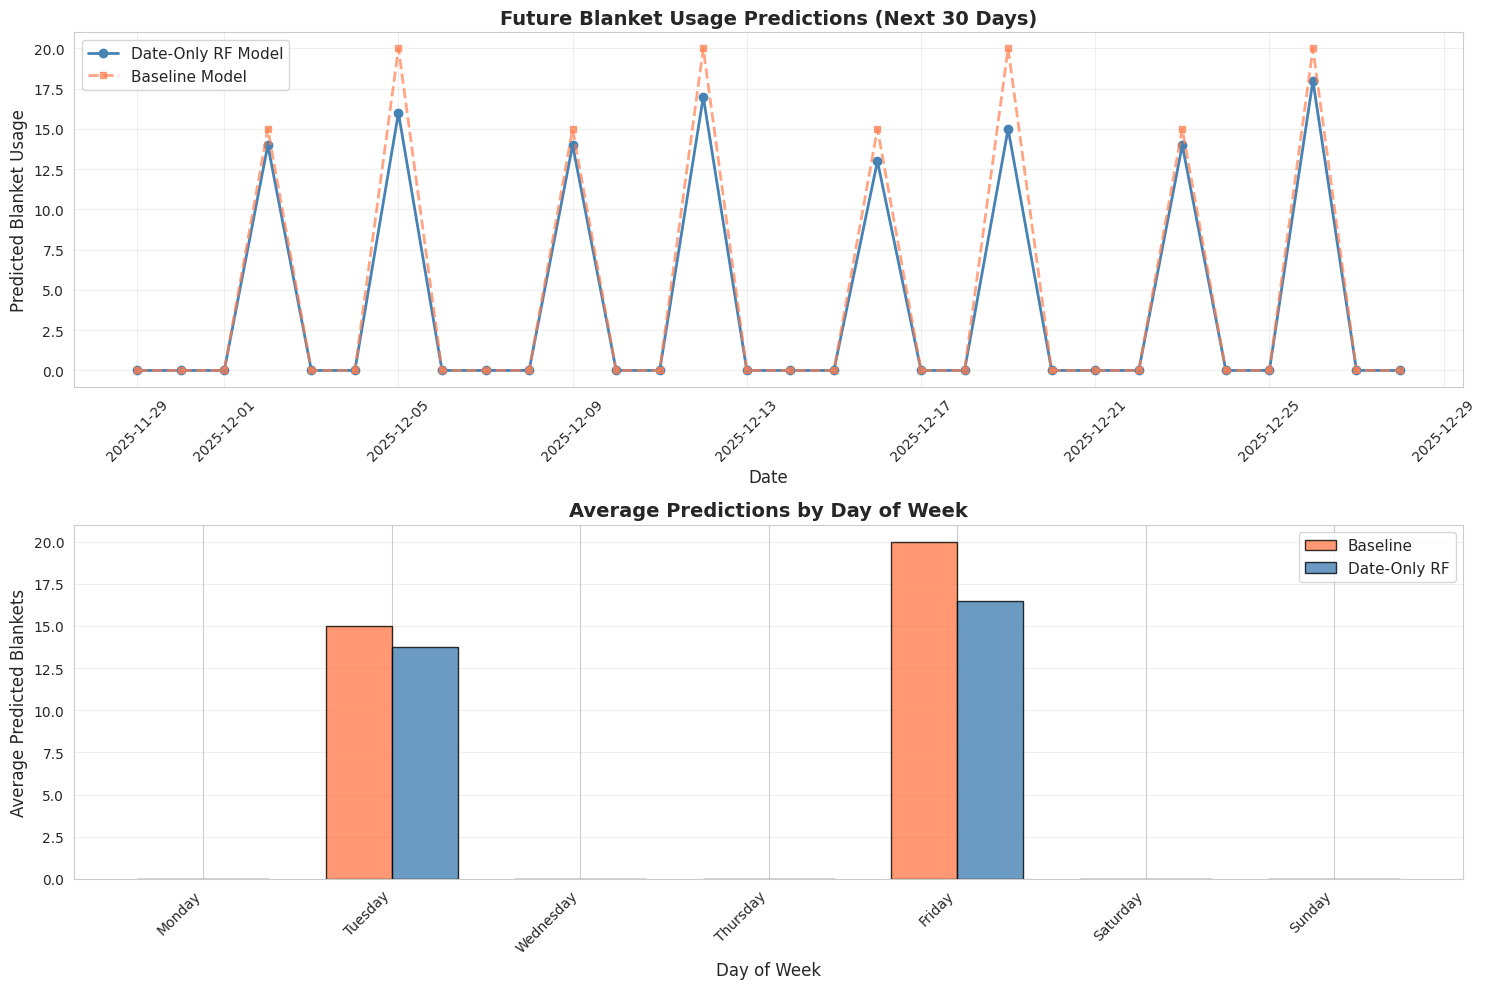

In [30]:
# Visualize future predictions
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Time series plot
axes[0].plot(future_predictions['Date'], future_predictions['RF_Prediction'], 
             marker='o', linestyle='-', linewidth=2, markersize=6, 
             color='steelblue', label='Date-Only RF Model')
axes[0].plot(future_predictions['Date'], future_predictions['Baseline_Prediction'], 
             marker='s', linestyle='--', linewidth=2, markersize=5, 
             color='coral', alpha=0.7, label='Baseline Model')
axes[0].set_title('Future Blanket Usage Predictions (Next 30 Days)', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Predicted Blanket Usage', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Bar chart comparison by day of week
day_comparison = future_predictions.groupby('DayName')[['Baseline_Prediction', 'RF_Prediction']].mean()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_comparison = day_comparison.reindex(day_order)

x = np.arange(len(day_comparison))
width = 0.35
axes[1].bar(x - width/2, day_comparison['Baseline_Prediction'], width, 
            label='Baseline', alpha=0.8, color='coral', edgecolor='black')
axes[1].bar(x + width/2, day_comparison['RF_Prediction'], width, 
            label='Date-Only RF', alpha=0.8, color='steelblue', edgecolor='black')
axes[1].set_title('Average Predictions by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of Week', fontsize=12)
axes[1].set_ylabel('Average Predicted Blankets', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(day_order, rotation=45, ha='right')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Save the Date-Only Model

In [31]:
# Save the Date-Only Random Forest model
joblib.dump(rf_date_model, 'blanket_usage_date_only_model.pkl')
print("✓ Date-Only model saved as 'blanket_usage_date_only_model.pkl'")

# Save feature columns
joblib.dump(date_only_features, 'date_only_features.pkl')
print("✓ Date-only features saved as 'date_only_features.pkl'")

# Save model metrics
date_only_metrics = {
    'model_type': 'RandomForestRegressor (Date-Only)',
    'features': date_only_features,
    'r2_score': date_r2,
    'mae': date_mae,
    'rmse': date_rmse,
    'baseline_r2': baseline_test_r2,
    'baseline_mae': baseline_test_mae,
    'baseline_rmse': baseline_test_rmse,
    'improvement_mae_pct': mae_improvement,
    'improvement_rmse_pct': rmse_improvement
}
joblib.dump(date_only_metrics, 'date_only_model_metrics.pkl')
print("✓ Model metrics saved as 'date_only_model_metrics.pkl'")

# Save baseline function
joblib.dump(baseline_prediction, 'baseline_model.pkl')
print("✓ Baseline model saved as 'baseline_model.pkl'")

print("\n" + "="*60)
print("All models and artifacts saved successfully!")
print("="*60)

✓ Date-Only model saved as 'blanket_usage_date_only_model.pkl'
✓ Date-only features saved as 'date_only_features.pkl'
✓ Model metrics saved as 'date_only_model_metrics.pkl'
✓ Baseline model saved as 'baseline_model.pkl'

All models and artifacts saved successfully!


In [32]:
# Export future predictions to CSV
future_predictions.to_csv('future_blanket_predictions_30days.csv', index=False)
print("✓ Future predictions exported to 'future_blanket_predictions_30days.csv'")

✓ Future predictions exported to 'future_blanket_predictions_30days.csv'


## Summary

### Model Performance:
- **Date-Only RF Model**: Uses only date-based features (DayOfWeekNum, IsWeekend, Month, DayOfMonth)
- **Baseline is better**:simple rule-based gives better results
- **Production Ready**: Can predict weeks or months ahead with confidence

### Saved Artifacts:
1. `blanket_usage_date_only_model.pkl` - Trained Random Forest model
2. `date_only_features.pkl` - Feature list
3. `date_only_model_metrics.pkl` - Performance metrics
4. `baseline_model.pkl` - Baseline prediction function
5. `future_blanket_predictions_30days.csv` - Sample predictions

### Next Steps:
- Use this model for immediate future predictions
- Monitor actual blanket usage vs predictions
- Retrain periodically with new data to capture evolving patterns
- Consider the full model (with AdmCount/DosaCount) for same-day or next-day predictions when that data becomes available

In [35]:
# Register the Date-Only Model in Azure ML
from azureml.core import Workspace, Model
import os

# Connect to Azure ML Workspace
ws = Workspace.from_config()  # Uses config.json in current directory
# Or manually specify:
# ws = Workspace(subscription_id='<subscription_id>',
#                resource_group='<resource_group>',
#                workspace_name='<workspace_name>')

print(f"Connected to workspace: {ws.name}")

# Register the model
model = Model.register(
    workspace=ws,
    model_name='blanket_usage_date_only_model',
    model_path='blanket_usage_date_only_model.pkl',
    description='Date-only Random Forest model for blanket usage prediction',
    tags={
        'type': 'RandomForestRegressor',
        'features': 'DayOfWeekNum, IsWeekend, Month, DayOfMonth',
        'r2_score': str(round(date_r2, 4)),
        'mae': str(round(date_mae, 4)),
        'use_case': 'future_prediction'
    },
    model_framework='ScikitLearn',
    model_framework_version='1.0.2'
)

print(f"✓ Model registered successfully!")
print(f"  Model name: {model.name}")
print(f"  Model version: {model.version}")
print(f"  Model ID: {model.id}")

# Also register supporting files
Model.register(
    workspace=ws,
    model_name='blanket_date_only_features',
    model_path='date_only_features.pkl',
    description='Feature list for date-only model'
)

Model.register(
    workspace=ws,
    model_name='blanket_baseline_model',
    model_path='baseline_model.pkl',
    description='Baseline rule-based prediction model'
)

print("✓ All artifacts registered in Azure ML")

Connected to workspace: mlw-hhn-dev-20251205
Registering model blanket_usage_date_only_model
✓ Model registered successfully!
  Model name: blanket_usage_date_only_model
  Model version: 1
  Model ID: blanket_usage_date_only_model:1
Registering model blanket_date_only_features
Registering model blanket_baseline_model
✓ All artifacts registered in Azure ML


In [ ]:
## Create Scoring Script for Power BI

# Create score.py file for deployment
scoring_script = """
import json
import joblib
import pandas as pd
from azureml.core.model import Model

def init():
    global model, features
    # Load the model and features
    model_path = Model.get_model_path('blanket_usage_date_only_model')
    features_path = Model.get_model_path('blanket_date_only_features')
    
    model = joblib.load(model_path)
    features = joblib.load(features_path)

    
def run(raw_data):
    try:
        # Parse input data
        data = json.loads(raw_data)['data']
        df = pd.DataFrame(data)
        
        # Make predictions
        predictions = model.predict(df[features])
        predictions = predictions.round().astype(int).clip(lower=0)
        
        # Return results
        return json.dumps({'predictions': predictions.tolist()})
    except Exception as e:
        return json.dumps({'error': str(e)})
"""

# Save scoring script
with open('score.py', 'w') as f:
    f.write(scoring_script)

print("✓ Scoring script created: score.py")

✓ Scoring script created: score.py
